# Exploratory Data Analysis
Raw AI4Arctic Sea Ice Challenge Test Dataset

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Load the data


Sea Ice Concentration (SIC) — the ratio of ice to open water
Stage of Development (SOD) — ice type, which is a proxy for thickness
Floe Size (FLOE) — the size of ice chunks, relevant to navigation

In [4]:
data = xr.open_dataset("../S1A_EW_GRDM_1SDH_20180124T194759_20180124T194859_020301_022AA4_1F75_icechart_dmi_201801241950_SouthEast_RIC.nc", engine="netcdf4")
print(data)
print(list(data.data_vars))
print(data.dims)

<xarray.Dataset> Size: 2GB
Dimensions:                  (sar_lines: 10006, sar_samples: 10458,
                              sar_grid_points: 441, 2km_grid_lines: 200,
                              2km_grid_samples: 209, polygon_codes: 27)
Coordinates:
  * polygon_codes            (polygon_codes) <U56 6kB 'poly_id;CT;CA;SA;FA;CB...
Dimensions without coordinates: sar_lines, sar_samples, sar_grid_points,
                                2km_grid_lines, 2km_grid_samples
Data variables: (12/32)
    nersc_sar_primary        (sar_lines, sar_samples) float32 419MB ...
    nersc_sar_secondary      (sar_lines, sar_samples) float32 419MB ...
    polygon_icechart         (sar_lines, sar_samples) float32 419MB ...
    distance_map             (sar_lines, sar_samples) float32 419MB ...
    sar_grid_line            (sar_grid_points) float64 4kB ...
    sar_grid_sample          (sar_grid_points) float64 4kB ...
    ...                       ...
    u10m_rotated             (2km_grid_lines, 2km_grid_s

Key variables to consider are nersc_sar_primary, nersc_sar_secondary, sar_grid_incidenceangle 

## Summary Statistics

In [6]:
rows = []
for v in data.data_vars:
    arr = data[v].values
    flat = arr.flatten().astype(float)
    valid = flat[~np.isnan(flat) & (flat != 255)]
    rows.append({
        'variable': v,
        'shape': str(arr.shape),
        'dtype': arr.dtype,
        'mean': np.mean(valid),
        'std': np.std(valid),
        'min': round(float(valid.min()),3) if len(valid) else None,
        'max': round(float(valid.max()),3) if len(valid) else None,
    })
display(pd.DataFrame(rows))

/Users/yolandajian/arctic-showcase/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/yolandajian/arctic-showcase/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/yolandajian/arctic-showcase/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/yolandajian/arctic-showcase/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/yolandajian/arctic-showcase/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,variable,shape,dtype,mean,std,min,max
0,nersc_sar_primary,"(10006, 10458)",float32,-15.224570,6.048548,-83.149,19.607
1,nersc_sar_secondary,"(10006, 10458)",float32,-25.657054,4.476885,-83.462,27.609
2,polygon_icechart,"(10006, 10458)",float32,25.898525,5.055370,3.000,31.000
3,distance_map,"(10006, 10458)",float32,29.040578,12.566658,0.000,41.000
4,sar_grid_line,"(441,)",float64,5009.285714,3032.527504,0.000,10005.000
5,sar_grid_sample,"(441,)",float64,5229.857143,3166.686405,0.000,10457.000
6,sar_grid_latitude,"(441,)",float64,64.703523,1.102691,62.497,66.858
7,sar_grid_longitude,"(441,)",float64,-35.204997,2.660750,-40.704,-30.235
8,sar_grid_incidenceangle,"(441,)",float64,33.975946,8.297456,19.111,46.712
9,sar_grid_height,"(441,)",float64,0.000000,0.000000,0.000,0.000


## Visualization

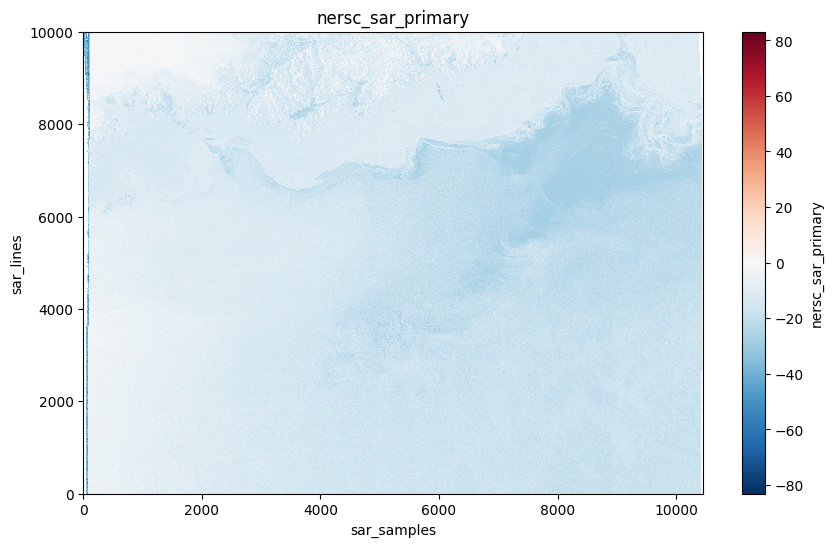

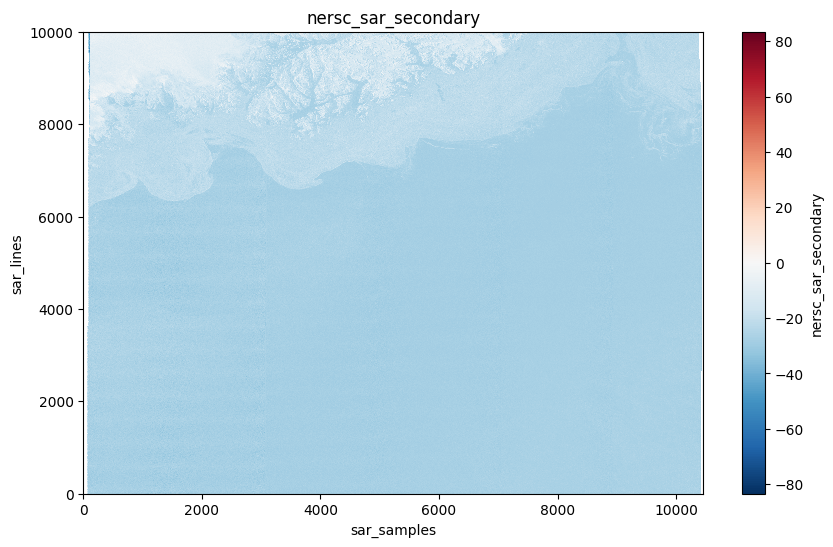

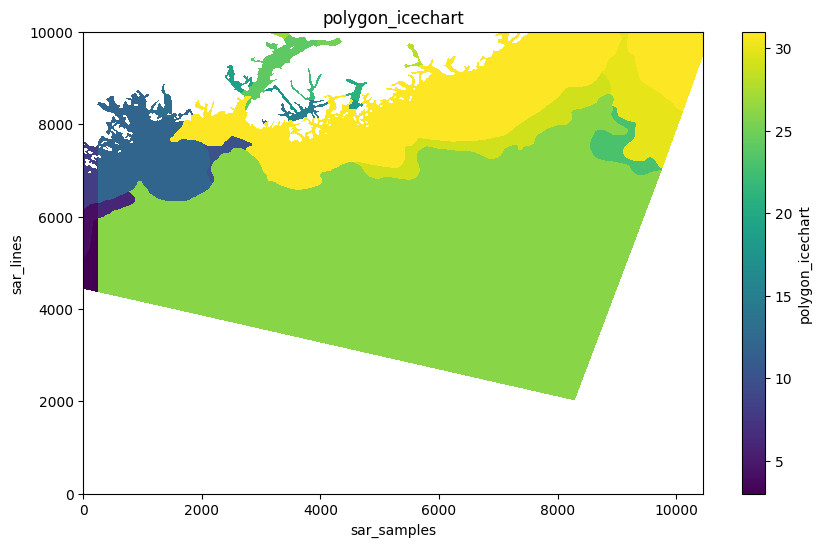

In [ ]:
for var in ['nersc_sar_primary', 'nersc_sar_secondary', 'polygon_icechart']:
    plt.figure(figsize=(10, 6))
    data[var].plot()
    plt.title(var)
    plt.show()

## Visualize the SAR bands

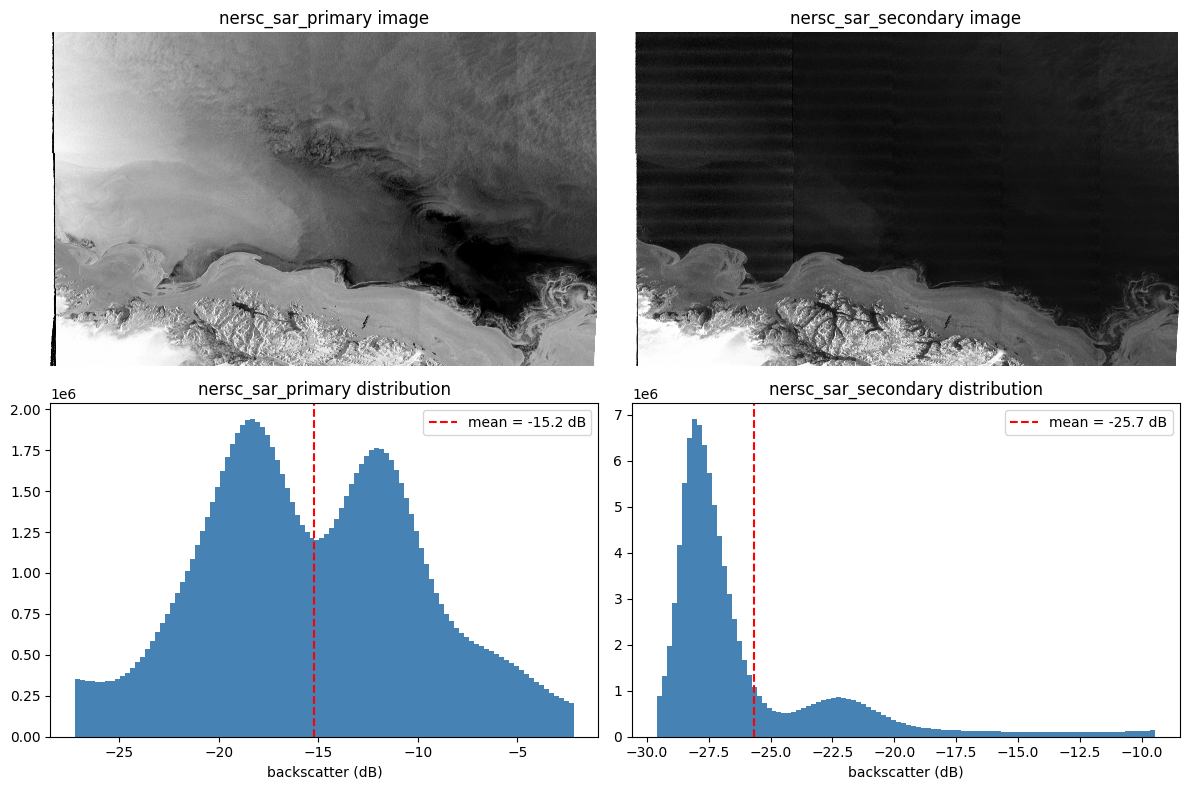

In [ ]:
sar_vars = [v for v in ['nersc_sar_primary', 'nersc_sar_secondary'] if v in data]

fig, axes = plt.subplots(2, len(sar_vars), figsize=(12, 8))

for i, var in enumerate(sar_vars):
    pols = data[var].attrs.get('polarization', var) # reading "HH" or "HV"
    arr = data[var].values.astype(float)
    flat = arr[~np.isnan(arr)].flatten()      

    lo,hi = np.percentile(flat,2), np.percentile(flat,98)      

    img = np.clip((arr - lo) / (hi - lo), 0, 1) # normalize to [0,1]
    axes[0,i].imshow(img, cmap='gray', aspect='auto')
    axes[0,i].set_title(f'{pols} image')
    axes[0,i].axis('off')

    axes[1,i].hist(flat, bins=100, range=(lo, hi), color='steelblue')
    axes[1,i].axvline(flat.mean(), color='red', linestyle='dashed', label=f'mean = {flat.mean():.1f} dB')
    axes[1,i].set_xlabel("backscatter (dB)")
    axes[1,i].set_title(f'{pols} distribution')
    axes[1,i].legend()


plt.tight_layout()
plt.show()


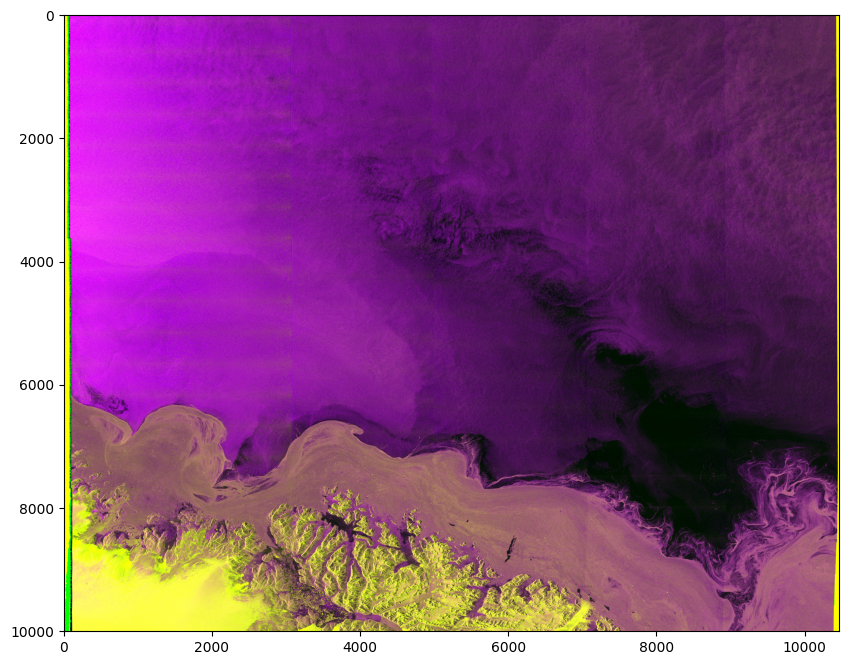

In [9]:
def norm(arr, lo=2, hi=98):
    a = arr.astype(float).copy()
    a[np.isnan(a)] = 0
    valid = a[a != 0]
    lo_val = np.percentile(valid, lo)
    hi_val = np.percentile(valid, hi)
    return np.clip((a - lo_val) / (hi_val - lo_val), 0, 1)

hh  = data['nersc_sar_primary'].values.astype(float)
hv  = data['nersc_sar_secondary'].values.astype(float)

ratio = hh - hv
ratio[np.isnan(hh)  | np.isnan(hv)] = np.nan

R = norm(hh)
G = norm(hv)
B = norm(ratio)

rgb = np.dstack([R, G, B])
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(rgb, aspect='auto')



## Coefficient Correlation